In [54]:
# Ignore all other GPUs except this one
!export CUDA_VISIBLE_DEVICES=1

In [55]:
plt.style.available

['Solarize_Light2',
 '_classic_test_patch',
 '_mpl-gallery',
 '_mpl-gallery-nogrid',
 'bmh',
 'classic',
 'dark_background',
 'fast',
 'fivethirtyeight',
 'ggplot',
 'grayscale',
 'petroff10',
 'seaborn-v0_8',
 'seaborn-v0_8-bright',
 'seaborn-v0_8-colorblind',
 'seaborn-v0_8-dark',
 'seaborn-v0_8-dark-palette',
 'seaborn-v0_8-darkgrid',
 'seaborn-v0_8-deep',
 'seaborn-v0_8-muted',
 'seaborn-v0_8-notebook',
 'seaborn-v0_8-paper',
 'seaborn-v0_8-pastel',
 'seaborn-v0_8-poster',
 'seaborn-v0_8-talk',
 'seaborn-v0_8-ticks',
 'seaborn-v0_8-white',
 'seaborn-v0_8-whitegrid',
 'tableau-colorblind10']

In [56]:
import torch
from torch import nn
from torch import optim
from torch.autograd import grad
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
import torch.jit as jit

import numpy as np
import matplotlib.pyplot as plt

import os
import time
import pickle
import tqdm
import random
import typing
import itertools
from typing import Union
from datetime import datetime

plt.style.use('seaborn-v0_8-poster')
# import LBFGS
# from LBFGS import FullBatchLBFGS

Here we are defining our quantities from analytical theory. \
We will assume all perturbed quantities $(E,B,\vec{v_e}, n_e)$ vary ~ $e^{i(kx-\omega t)}$ 

Dispersion relation is as follows: $N^2 = \frac{K^2 - D^2}{K}$\
where $N^2 = \frac{c^2k^2}{\omega^2}, K = 1- \frac{\omega_{pe}}{\omega^2 - \omega_{ce}^2}, D = \frac{\omega_{ce}}{\omega}\frac{\omega_{pe}}{\omega^2 - \omega_{ce}^2}$

In [57]:
#Define Physical Parameters

vth = 0.1 #thermal velocity in units of c (c=1)

#frequencies in units of omega_pe
omega_ce = 2.0 #electron cyclotron frequency
omega = 2.5 #For our choice of omega_ce, the cutoff omega_R/omega_ce ~2.44, so choose to set omega = 2.5
omega_pe = 1.0 #plasma frequency, normalized to itself

E_amp = 1.0 #Amplitude of Electric Field in units of omega_pe*(mc/e)

#calculate k from dispersion relation
def x_wave_dispersion(omega, omega_ce, omega_pe):
    """
    Function to calculate the wave number k and the normalized wave number k_lambda_D.
    
    Inputs:
    -omega(float):  wave frequency normalized to plasma frequency (omega_pe)
    -omega_ce(float): electron cyclotron frequency normalized to plasma frequency (omega_pe)
    -omega_pe(float): plasma frequency normalized to itself (usually set to 1)
    
    Outputs:
    -k(float): wave number in units of omega_pe/c
    -k_lambda_D(float): Unitless product k*lambda_D, where lambda_D is the Debye length.
    """
    
    c=1 #just for clarity
    factor = omega_pe**2/ (omega**2 - omega_ce**2)
    K = 1-factor
    D = (omega_ce/omega) * factor
    csq_ksq = omega**2 * (K**2 - D**2)/K
    
    k = np.sqrt(csq_ksq/c)
    k_lambda_D = k*vth
    
    return k, k_lambda_D

In [58]:
k, k_lambda_D = x_wave_dispersion(omega, omega_ce, omega_pe)
print(f"k = {k:.3f}, k*lambda_D = {k_lambda_D:.3f}")

k = 1.432, k*lambda_D = 0.143


Here, we generate our data from analytical theory. 

In [59]:
def check_size_eq(lst):
    """Check if all lists in lst have the same size."""
    return not any(len(lst[0])!= len(i) for i in lst)

def phase_factor(delta):
    """Calculate the phase factor for the wave solution."""
    return np.exp(1j*delta)

def analytical_solution(x, t, omega, k, E_amp, delta):
    
    E_amp *= phase_factor(delta)
    
    c=1 #just for clarity
    factor_dielectric = omega_pe**2/ (omega**2 - omega_ce**2)
    factor_freq = omega_ce/(omega_pe*omega)
    K = 1-factor_dielectric
    D = (omega_ce/omega) * factor_dielectric
    Nsq = (c**2 * k**2)/omega**2
    
    Ex = E_amp * np.exp(1j*(k*x - omega*t)) #longtiduninal electrostatic part (vector)
    Ey = Ex * 1j*D/(K-Nsq) #transverse electromagnetic part
    Bz = k*Ey*t #(vector)
    Vx = (1/omega)*(-1j*Ex - factor_freq*Ey)*(1/(1-factor_freq)) #(vector)
    Vy = (1/omega)*(-1j*Ey - factor_freq*Ex)*(1/(1-factor_freq))
    N = (k/omega) * Vx #(scaler) N' = N/N0
    phi = (1j/k)*Ex #(scaler) phi measurements
    Bdot = -1j*omega*Bz #(vector) Bdot measurements (z direction)
    P = vth**2 * (N**3) #(scaler) electron pressure
     
    return Ex, Ey, Bz, Vx, Vy, phi, Bdot, N, P


def generate_data(xmin, xmax, tmin, tmax, nx, nt, omega_list, E_amp_list, delta_list):

    if not check_size_eq([omega_list, E_amp_list, delta_list]):
        raise Exception("Parameter lists are not the same size!")

    x = np.linspace(xmin, xmax, nx)
    t = np.linspace(tmin, tmax, nt)

    x_arr, t_arr = np.meshgrid(x,t)

    Ex = np.zeros_like(x_arr, dtype=np.complex128)
    Ey = np.zeros_like(x_arr, dtype=np.complex128)
    Bz = np.zeros_like(x_arr, dtype=np.complex128)
    Vx = np.zeros_like(x_arr, dtype=np.complex128)
    Vy = np.zeros_like(x_arr, dtype=np.complex128)
    N = np.zeros_like(x_arr, dtype=np.complex128)
    phi = np.zeros_like(x_arr, dtype=np.complex128)
    Bdot = np.zeros_like(x_arr, dtype=np.complex128)
    P = np.zeros_like(x_arr, dtype=np.complex128)

    for i in range(len(omega_list)):
        temp_Ex, temp_Ey, temp_Bz, temp_Vx, temp_Vy, temp_N, temp_phi, temp_Bdot, temp_P = analytical_solution(x_arr, t_arr, omega_list[i], \
                                                               x_wave_dispersion(omega_list[i], omega_ce, omega_pe)[0], \
                                                               E_amp_list[i], delta_list[i])
        Ex += temp_Ex
        Ey += temp_Ey
        Bz += temp_Bz
        Vx += temp_Vx
        Vy += temp_Vy
        N += temp_N
        phi += temp_phi
        Bdot += temp_Bdot
        P += temp_P

    return x_arr.flatten(), t_arr.flatten(), np.real(Ex).flatten(),np.real(Ey).flatten(), \
            np.real(Bz).flatten(), np.real(Vx).flatten(), np.real(Vy).flatten(), \
            np.real(phi).flatten(), np.real(Bdot).flatten(), np.real(P).flatten()


def sparse_measurements(x, t, phi, Bdot, num_samples):

    indices = np.random.choice(x.shape[0], num_samples, replace=False)

    return x[indices], t[indices], phi[indices], Bdot[indices]


def collocation_points(xmin, xmax, tmin, tmax, Nx, Nt, L, tau):

    x = np.linspace(xmin, xmax, Nx)
    t = np.linspace(tmin, tmax, Nt)

    x_coll, t_coll = np.meshgrid(x, t)

    dx = x[1] - x[0]
    dt = t[1] - t[0]

    return x_coll.flatten(), t_coll.flatten(), dx, dt

In [ ]:
omega_list = [omega]
E_amp_list = [E_amp]  # Amplitude of the electric field
delta_list = [0.0]  # Phase factor for the wave solution

lamda = 2 * np.pi / k  # Wavelength
T = (2 * np.pi) / omega  # Period of the wave
xmin, xmax = 0, 3*lamda
tmin, tmax = 0, 3*T

L = xmax - xmin  # Length of the domain
tau = tmax - tmin  # Time duration of the wave
Nt = 2000 # Number of time points
Nx = 2000 # Number of spatial points
Nt_coll = 200 
Nx_coll = 200
dt = T/float(Nt)
dx = L/float(Nx)

t_arr = np.linspace(tmin, tmax, Nt)
x_arr = np.linspace(xmin, xmax, Nx)

print(f"k = {k:.4e}")
print(f"k lambda_debye = {k_lambda_D:.4e}")
print(f"L = {L:.3e} [c / omega_pe]")
print(f"T = {T:.3e} [1 / omega_pe]")
print(f"dx = {dx:.3e} [c / omega_pe]")
print(f"dt = {dt:.3e} [1 / omega_pe]")

X_flat, T_flat, Ex_flat, Ey_flat, Bz_flat, Vx_flat, Vy_flat, phi_flat, Bdot_flat, P_flat = generate_data(
xmin, xmax, tmin, tmax, Nx, Nt, omega_list, E_amp_list, delta_list)

x_sparse, t_sparse, phi_sparse, Bdot_sparse = sparse_measurements(X_flat, T_flat, phi_flat, Bdot_flat, num_samples=200)

x_coll, t_coll, dx, dt = collocation_points(xmin, xmax, tmin, tmax, Nx_coll, Nt_coll, L, tau)

k = 1.4318e+00
k lambda_debye = 1.4318e-01
L = 1.317e+01 [c / omega_pe]
T = 2.513e+00 [1 / omega_pe]
dx = 6.583e-03 [c / omega_pe]
dt = 1.257e-03 [1 / omega_pe]


We are more interested in $\nabla P_{e}$, so we will take the derivative along the electrostatic part.

In [66]:
from PINN_Langmuir.ipynb import derivative_x, derivative_t

P_x = derivative_x(P_flat, x_arr, dx)
P_t = derivative_t(P_flat, t_arr, dt)

ModuleNotFoundError: No module named 'PINN_Langmuir'

TypeError: unhashable type: 'numpy.ndarray'

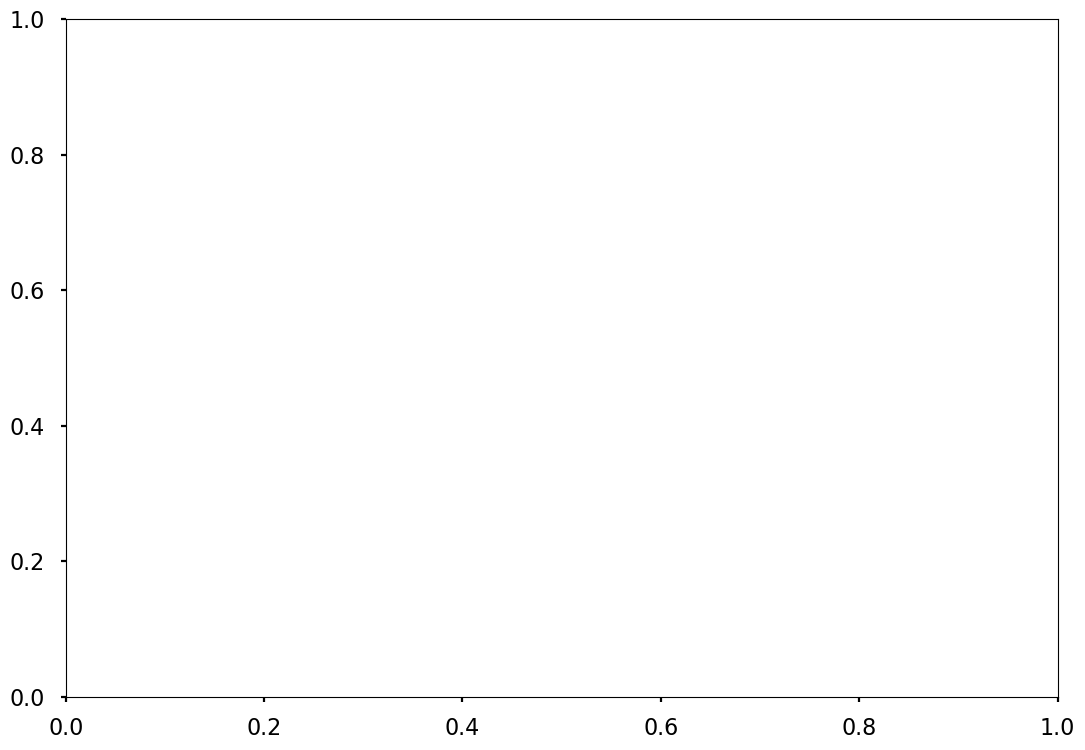

In [ ]:
def plot_analytical():
    """Plot the analytical solution."""
    titles = ['Ex (electrostatic)', 'Ey (electromagnetic)', 'Bz (magnetic field)',
              'Vx (velocity x)', 'Vy (velocity y)', 'phi (scalar potential)', 
             'Bdot (time derivative of B)', 'N (electron density)', 'P (pressure)']
    plt.figure(figsize=(12, 6))
    plt.plot(x_arr, Ex_flat[:Nx], label='Ex', color='blue')
    plt.plot(x_arr, Ey_flat[:Nx], label='Ey', color='orange')
    plt.plot(x_arr, Bz_flat[:Nx], label='Bz', color='green')
    
    plt.title('Analytical Solution of the Wave Equation')
    plt.xlabel('x (normalized)')
    plt.ylabel('Field Amplitude (normalized)')
    plt.legend()
    plt.grid()
    plt.show()